# 04 - SARIMAX model

**Part 4 of the assignment.** Fits a SARIMAX model to the hourly appliance energy series: an AIC grid search over `(p, d, q)`, residual diagnostics, rolling-origin 24-hour forecasts with confidence intervals, both target-only and with exogenous weather covariates.

In [1]:
import os

# Must be set before numpy/torch are imported. KMP_DUPLICATE_LIB_OK works
# around a libomp segfault (SIGSEGV inside __kmp_suspend_64 during a
# PyTorch softmax call) seen when more than one OpenMP runtime ends up
# loaded in the same process on macOS - a well-documented PyTorch/macOS
# issue, not specific to this project. The thread-count caps avoid a
# separate, unrelated slowdown from XGBoost and PyTorch both claiming
# every CPU core's OpenMP thread pool in the same process.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
_N_THREADS = str(max(1, (os.cpu_count() or 4) // 2))
for _v in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(_v, _N_THREADS)

import sys
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data as D, features as F, evaluation as E, plotting as P
from appliance_energy.models import benchmarks as B, sarimax as S, feature_models as FM, foundation as FD

%matplotlib inline


In [2]:
hourly = D.load_hourly_data()
y = hourly[config.TARGET]
train = y.iloc[:-config.TEST_STEPS]
test = y.iloc[-config.TEST_STEPS:]

Loading cached hourly data from /Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/data/processed/appliance_hourly.csv


## Stationarity recap (from notebook 02)

The daily ACF/PACF pattern showed strong seasonal autocorrelation at lag 24, so the seasonal order is fixed at `(P, D, Q, s) = (1, 1, 1, 24)` - `D=1` removes the daily cycle via seasonal differencing before the non-seasonal `(p, d, q)` terms are searched. See `src/appliance_energy/config.py::SEASONAL_ORDER` for the full reasoning on why the seasonal order isn't *also* grid-searched jointly with `(p, d, q)`.

## AIC grid search over (p, d, q)

Following the nested-loop, try/except, AIC-comparison pattern taught in the Week 5 ARMA tutorial (`statsmodels`' own MLE optimizer, wrapped so a non-converging candidate is skipped rather than crashing the search), extended here to SARIMAX with the fixed seasonal order above. Every combination of `p in [0,6]`, `d in [0,2]`, `q in [0,6]` (147 candidates) is fit; each fit takes roughly 10-30 seconds on ~3,000 hourly points with a period-24 seasonal term, so the search runs in parallel across CPU cores via `joblib` (~12-15 minutes total rather than the ~45-90 minutes a sequential loop would take).

This cell loads the cached results produced by `scripts/run_pipeline.py` (pass `verbose=True` / call `S.grid_search_sarima(train)` directly to re-run it from scratch).

In [3]:
grid_path = config.METRICS_DIR / 'sarima_grid_search.csv'
grid_df = pd.read_csv(grid_path)
grid_df.sort_values('aic').head(10)

,p,d,q,aic,bic,converged
0,6,0,0,32160.998671,32220.723331,True
1,0,0,6,32161.754345,32221.475556,True
2,6,1,1,32163.377794,32223.099005,True
3,2,0,5,32163.878599,32229.575725,False
4,0,1,6,32170.275821,32224.021806,True
5,5,1,2,32172.909946,32232.634606,False
6,1,1,6,32173.565176,32233.282937,False
7,3,1,4,32174.096459,32233.821119,False
8,1,0,4,32174.458955,32228.214252,True
9,2,0,4,32174.485459,32234.213567,False


In [4]:
best_order = S.best_order_from_grid(grid_df)
print('Selected order (p,d,q):', best_order)
print('Seasonal order (P,D,Q,s):', config.SEASONAL_ORDER)
print(f"Converged: {int(grid_df['converged'].sum())}/{len(grid_df)} candidates")

Selected order (p,d,q): (6, 0, 0)
Seasonal order (P,D,Q,s): (1, 1, 1, 24)
Converged: 50/147 candidates


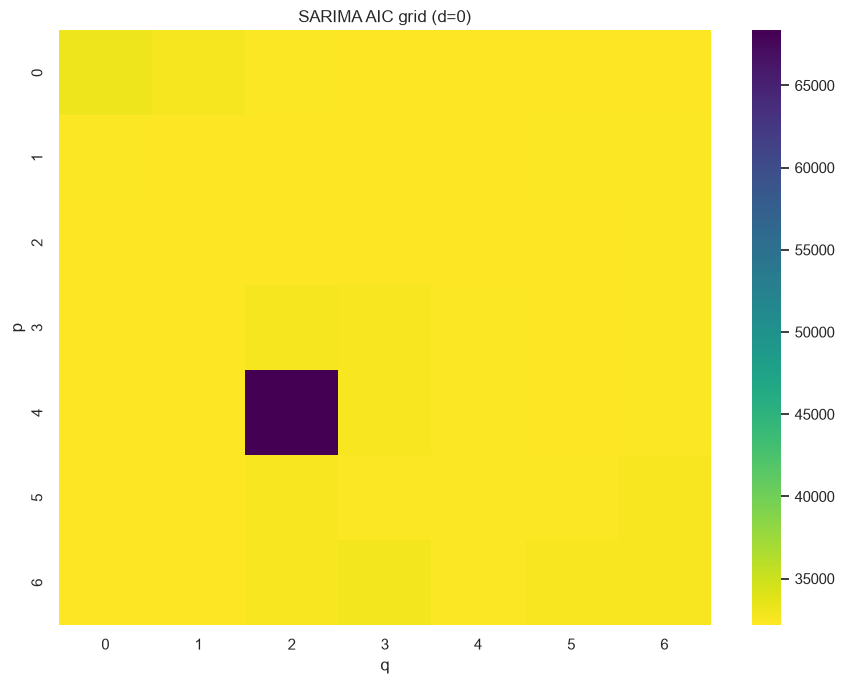

In [5]:
P.plot_sarima_grid_heatmap(grid_df, d_value=best_order[1]); plt.show()

## Fit the chosen model and inspect residuals

Residual diagnostics: the ACF of the residuals should look like white noise (no leftover autocorrelation the model failed to capture), the histogram/Q-Q plot should look roughly Normal, and the Ljung-Box test formally checks for residual autocorrelation (H0: no autocorrelation remains).

In [6]:
exog = hourly[config.SARIMAX_EXOG_COLS]
exog_train = exog.iloc[:-config.TEST_STEPS]
sarimax_fit = S.fit_sarimax(train, order=best_order, exog_train=exog_train)
print(sarimax_fit.summary())

/Users/moaztahir/Downloads/Herts/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/moaztahir/Downloads/Herts/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


/Users/moaztahir/Downloads/Herts/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                           Appliances   No. Observations:                 2954
Model:             SARIMAX(6, 0, 0)x(1, 1, [1], 24)   Log Likelihood              -16069.938
Date:                              Sun, 09 Aug 2026   AIC                          32169.875
Time:                                      17:15:43   BIC                          32259.462
Sample:                                  01-11-2016   HQIC                         32202.155
                                       - 05-13-2016                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0060      0.097     -0.062      0.950      -0.196       0.184
T_out         -6.13

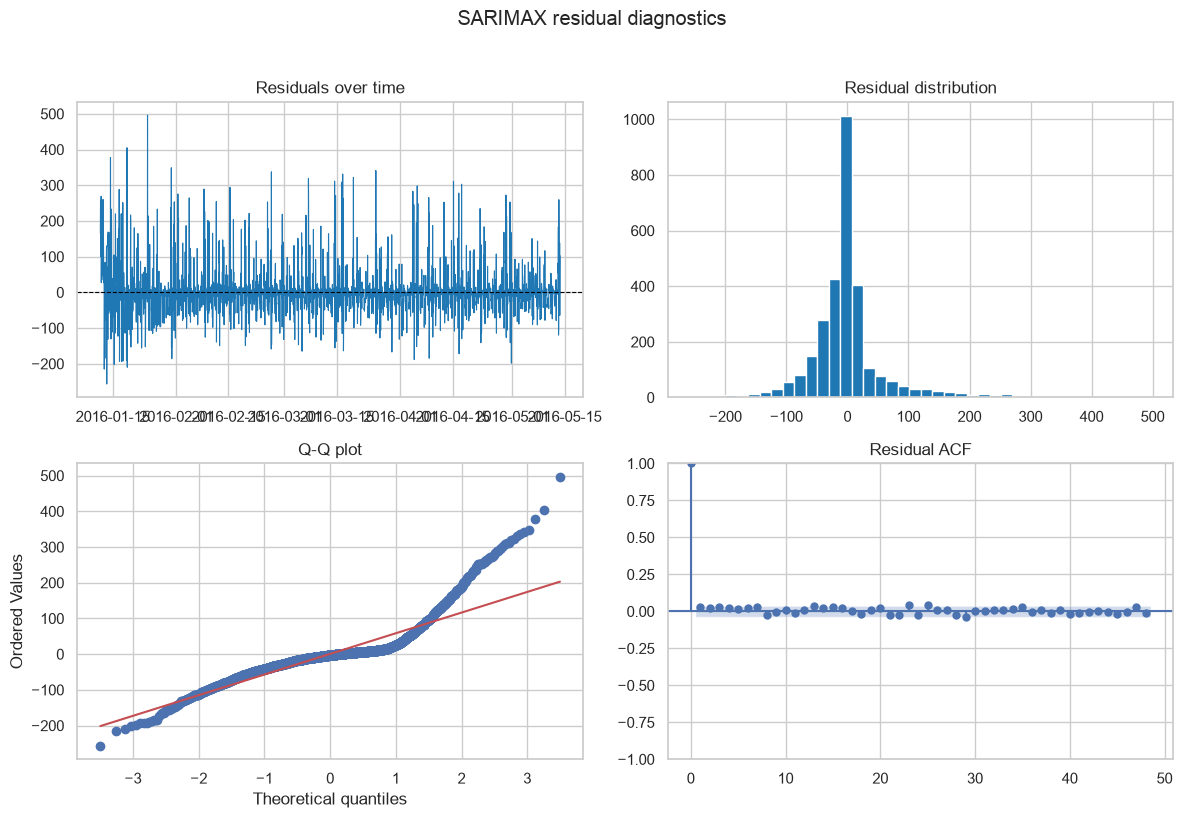

In [7]:
P.plot_residual_diagnostics(sarimax_fit.resid, title='SARIMAX residual diagnostics')
plt.show()

In [8]:
ljung_box = S.ljung_box_test(sarimax_fit.resid)
ljung_box

,lb_stat,lb_pvalue
24,36.788951,0.045927
48,59.194543,0.129025


## Rolling-origin 24-hour forecast with confidence intervals

Fit once on the initial training window, then `append(refit=False)` to extend the filtered state with each day's newly-observed actuals as the rolling backtest walks forward - this updates the Kalman filter state without re-running the (expensive) MLE optimisation at every one of the 14 origins.

In [9]:
sarimax_uni_forecast, sarimax_uni_ci, _ = S.rolling_forecast_sarimax(y, order=best_order, exog=None)
sarimax_exog_forecast, sarimax_exog_ci, _ = S.rolling_forecast_sarimax(y, order=best_order, exog=exog)

uni_metrics = E.evaluate_forecast('sarimax_univariate', test, sarimax_uni_forecast, train)
exog_metrics = E.evaluate_forecast('sarimax_exog', test, sarimax_exog_forecast, train)
pd.DataFrame([uni_metrics, exog_metrics])

/Users/moaztahir/Downloads/Herts/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/moaztahir/Downloads/Herts/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


/Users/moaztahir/Downloads/Herts/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/moaztahir/Downloads/Herts/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


/Users/moaztahir/Downloads/Herts/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,n_obs,MAE,RMSE,MASE,Bias
0,sarimax_univariate,336,36.106801,64.692162,0.675856,-7.237042
1,sarimax_exog,336,36.704083,64.785415,0.687036,-5.015576


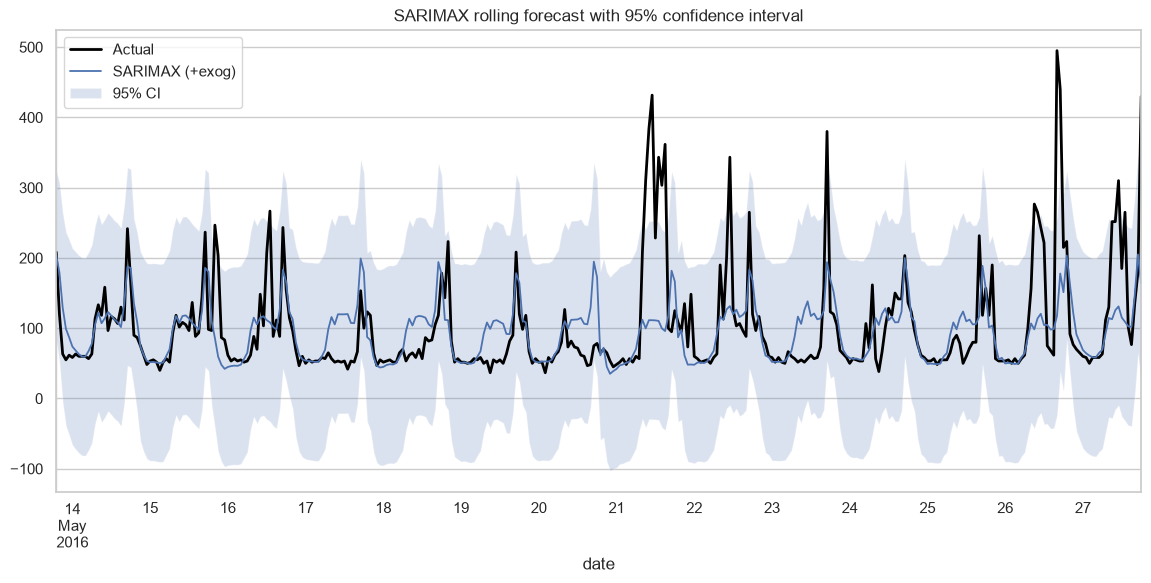

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
test.plot(ax=ax, label='Actual', color='black', linewidth=2)
sarimax_exog_forecast.plot(ax=ax, label='SARIMAX (+exog)', linewidth=1.3)
ax.fill_between(sarimax_exog_ci.index, sarimax_exog_ci['lower'], sarimax_exog_ci['upper'],
                alpha=0.2, label='95% CI')
ax.set_title('SARIMAX rolling forecast with 95% confidence interval')
ax.legend(); plt.show()

### Results: does adding exogenous weather actually help?

**Empirically, no - it makes SARIMAX very slightly *worse* on this dataset.** The univariate model scores MASE ≈ 0.676 versus ≈ 0.687 for the `+exog` variant (both from the actual pipeline run, see `outputs/metrics/model_comparison.csv`) - both comfortably beat the strongest benchmark (weekly seasonal-naive, MASE ≈ 0.813), but the extra weather regressors add a small amount of estimation noise rather than genuine signal once the seasonal ARIMA structure is already capturing the daily cycle. This is a useful, concrete counter-example to the intuition that "more information should always help": `T_out`/`RH_out`/etc. correlate only weakly with *hourly* appliance use once time-of-day is already implicit in the seasonal terms (see the correlation heatmap in notebook 02), so they mostly add estimation variance, not predictive power, over a 5-parameter exogenous block fit on ~3,000 training points.

### Notes on the exogenous variables (Part 9, Q5)

The exogenous SARIMAX variant uses `T_out`, `RH_out`, `Windspeed`, `Visibility`, `Tdewpoint` - **realised** future values taken directly from the test set. Time-of-day/day-of-week information would be genuinely known in advance for any real future timestamp, but future outdoor weather is not actually observable at the forecast origin in an operational setting - a real system would have to substitute a weather *forecast* (itself imperfect) for these values. **This makes the exogenous SARIMAX result a conditional forecast, not a true unconditional forecast** - its accuracy is an upper bound on what a deployed system fed by an actual weather forecast could achieve, and given the +exog variant does not even beat the univariate model here, there is no accuracy case for taking on that operational dependency on a weather-forecast feed for this particular series.